# Análisis Bivariable — Admisiones de Posgrado

**Autor:** SCO

**Fecha:** 2026-08-19

**Descripción:**
Notebook 2 del Issue #3 "Análisis Exploratorio de Datos (EDA)". El Issue divide el
EDA en tres notebooks: (1) análisis univariable (ya terminado), (2) análisis
**bivariable** (este notebook) y (3) análisis multivariable (posterior).

Este notebook estudia las **relaciones entre pares de variables**, con énfasis en la
relación entre cada predictor y el target `Chance of Admit`. Se trabaja sobre el
dataset preparado en el Issue #2 (`data/02_intermediate/Admission_Predict.parquet`).

El problema es de **regresión**: `Chance of Admit` es un target continuo acotado en
[0, 1]. No se entrena ningún modelo, no se calculan métricas de predicción y no se
hace split train/test: es un análisis **descriptivo** de asociaciones.

**No se afirma causalidad** en ningún punto; se usa lenguaje de asociación
("se observa", "se aprecia una tendencia", "los datos sugieren").

## 📚 Import libraries

In [1]:
# librerías base para ciencia de datos
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

## 💾 Load data

Lectura **reproducible** e **inmutable** del dataset preparado: se localiza la raíz
del repositorio (buscando `pyproject.toml`) y se lee el Parquet tipado producido por
el Issue #2. No se modifica ni el Parquet ni el CSV RAW.

In [2]:
def find_repo_root(start: Path) -> Path:
    """Localiza la raíz del repositorio subiendo hasta encontrar `pyproject.toml`."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz del repositorio (pyproject.toml).")


ROOT = find_repo_root(Path.cwd())
DATA_PATH = ROOT / "data" / "02_intermediate" / "Admission_Predict.parquet"

admission_df = pd.read_parquet(DATA_PATH)

admission_df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## 👷 Preparación de datos y perfil del dataset

Este notebook **no transforma los datos**: es un análisis de lectura sobre el dataset
entregado por el Issue #2. El perfil completo (tipos, nulos, duplicados, rangos,
distribuciones) ya fue documentado en el Notebook 1 (univariable); aquí solo se
recuerdan los elementos que afectan al análisis bivariable.

### Perfil del dataset (resumen)

In [3]:
TARGET = "Chance of Admit"
PREDICTORS = [
    "GRE Score",
    "TOEFL Score",
    "University Rating",
    "SOP",
    "LOR",
    "CGPA",
    "Research",
]

print(f"Shape (filas, columnas): {admission_df.shape}")
print()
print("Tipos por columna:")
print(admission_df.dtypes)
print()
print("Nulos por columna:")
print(admission_df.isna().sum())

Shape (filas, columnas): (623, 8)

Tipos por columna:
GRE Score              Int64
TOEFL Score            Int64
University Rating      Int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               Int64
Chance of Admit      float64
dtype: object

Nulos por columna:
GRE Score            11
TOEFL Score          19
University Rating     6
SOP                  16
LOR                   8
CGPA                  2
Research             29
Chance of Admit       0
dtype: int64


El dataset tiene **623 filas y 8 columnas** (7 predictores + el target). Resumen
relevante para este análisis (detalle en el Notebook 1):

- **Nulos**: 7 de 8 columnas tienen faltantes; `Chance of Admit` no tiene ninguno.
  `Research` (29) y `TOEFL Score` (19) son las que más.
- **Duplicados**: 152 filas completamente duplicadas (24.4 %); **no se eliminan**.
- **Tipos**: 4 enteras (`Int64`) y 4 continuas (`float64`).

**Cómo se manejan los nulos aquí**: no se imputan ni se eliminan del dataset. Para
calcular una asociación entre dos variables se usan las **observaciones válidas del
par** (complete-pairs), lo que reduce el `n` de cada relación de forma distinta según
los faltantes de cada columna. `admission_df` permanece intacto.

## 📊 Análisis de resultados y conclusiones

### 1. Asociación de cada predictor con el target

Primero, un panorama cuantitativo: para cada predictor se calcula la **correlación de
Pearson** (mide asociación lineal) y la de **Spearman** (basada en rangos, robusta a
no linealidad y a outliers), ambas con su p-valor y el número de pares completos.

In [4]:
def corr_with_target(col: str) -> pd.Series:
    """Correlación Pearson y Spearman de un predictor con el target (pares completos)."""
    data = admission_df[[col, TARGET]].dropna()
    r, p_pearson = stats.pearsonr(data[col], data[TARGET])
    rho, p_spearman = stats.spearmanr(data[col], data[TARGET])
    return pd.Series(
        {
            "Pearson r": r,
            "p (Pearson)": p_pearson,
            "Spearman rho": rho,
            "p (Spearman)": p_spearman,
            "n pares": len(data),
        }
    )


corr_target_df = pd.DataFrame({col: corr_with_target(col) for col in PREDICTORS}).T.sort_values(
    "Pearson r", ascending=False
)

corr_display = corr_target_df.copy()
corr_display["Pearson r"] = corr_display["Pearson r"].round(4)
corr_display["Spearman rho"] = corr_display["Spearman rho"].round(4)
corr_display["p (Pearson)"] = corr_display["p (Pearson)"].map(lambda v: f"{v:.2e}")
corr_display["p (Spearman)"] = corr_display["p (Spearman)"].map(lambda v: f"{v:.2e}")
corr_display["n pares"] = corr_display["n pares"].astype(int)

corr_display

,Pearson r,p (Pearson),Spearman rho,p (Spearman),n pares
CGPA,0.8832,1.09e-205,0.8897,5.59e-213,621
GRE Score,0.8214,7.22e-151,0.8338,1.66e-159,612
TOEFL Score,0.8132,1.28e-143,0.8225,1.11e-149,604
University Rating,0.6572,1.47e-77,0.6736,8.61e-83,617
SOP,0.6468,3.25e-73,0.6679,1.23e-79,607
LOR,0.6464,4.96e-74,0.6428,5.61e-73,615
Research,0.5664,1.06e-51,0.5925,1.43e-57,594


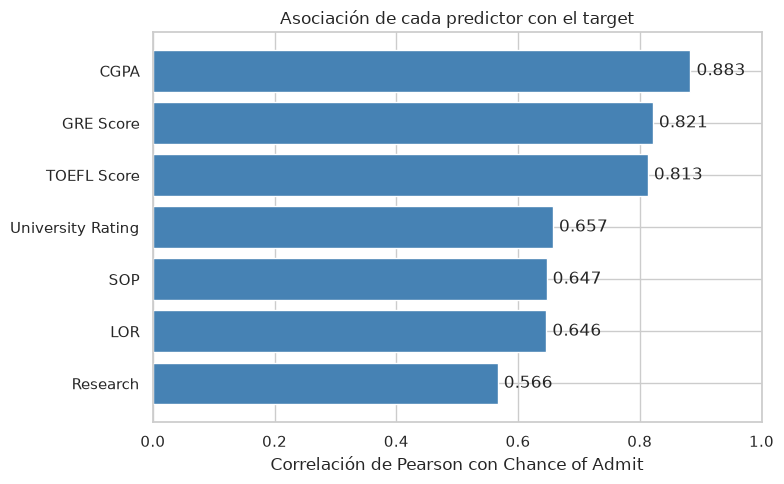

In [5]:
ranked = corr_target_df.sort_values("Pearson r", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(ranked.index, ranked["Pearson r"], color="steelblue")
for bar, value in zip(bars, ranked["Pearson r"], strict=True):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")
ax.set_xlim(0, 1)
ax.set_xlabel("Correlación de Pearson con Chance of Admit")
ax.set_title("Asociación de cada predictor con el target")
fig.tight_layout()
plt.show()

**Lectura de la asociación con el target** (correlación de Pearson, de mayor a
menor):

| Rank | Predictor | Pearson | Spearman |
| --- | --- | --- | --- |
| 1 | `CGPA` | 0.883 | 0.890 |
| 2 | `GRE Score` | 0.821 | 0.834 |
| 3 | `TOEFL Score` | 0.813 | 0.823 |
| 4 | `University Rating` | 0.657 | 0.674 |
| 5 | `SOP` | 0.647 | 0.668 |
| 6 | `LOR` | 0.646 | 0.643 |
| 7 | `Research` | 0.566 | 0.593 |

- **Mayor asociación**: `CGPA`, `GRE Score` y `TOEFL Score` (r ≈ 0.81–0.88), las tres
  con asociación fuerte y positiva.
- **Asociación moderada**: `University Rating`, `SOP` y `LOR` (r ≈ 0.65).
- **Asociación más débil**: `Research` (r ≈ 0.57), aunque sigue siendo positiva.
- Todas las asociaciones son **estadísticamente significativas** (p < 1e-50, ver tabla).
- **Significancia vs magnitud**: un p-value pequeño indica evidencia estadística de
  asociación, pero no implica por sí mismo una asociación de gran magnitud ni
  importancia práctica. Con ~600 observaciones pueden obtenerse p-values muy pequeños
  incluso para asociaciones de magnitud moderada. Por eso la interpretación debe leer
  conjuntamente el coeficiente de correlación (que informa sobre magnitud y dirección)
  y el p-value (que informa sobre la evidencia estadística). El análisis **no establece
  causalidad**.
- **Linealidad**: para todas las variables `Pearson` ≈ `Spearman` (diferencia < 0.03),
  lo que sugiere que las relaciones son aproximadamente **monótonas y lineales**, sin
  curvatura marcada. A continuación se estudia cada relación con su gráfica.

### 2. Predictores numéricos → target

Para `GRE Score`, `TOEFL Score` y `CGPA` (numéricos) se usa un **scatterplot con línea
de tendencia** (regresión lineal simple) más la correlación de **Pearson** (asociación
lineal) y **Spearman** (monótona). La comparación de ambas **complementa la lectura del
scatterplot** y puede aportar evidencia sobre posibles diferencias entre asociaciones
lineales y monotónicas (p. ej., si Spearman fuera mucho mayor que Pearson). El
scatterplot sigue siendo la evidencia visual principal para evaluar la forma de la
relación; la comparación Pearson/Spearman no es una prueba formal de linealidad.

In [6]:
def plot_scatter_target(col: str) -> None:
    """Scatterplot con línea de tendencia lineal de un predictor numérico vs target."""
    data = admission_df[[col, TARGET]].dropna()
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.regplot(
        data=data,
        x=col,
        y=TARGET,
        scatter_kws={"alpha": 0.5, "s": 18},
        line_kws={"color": "crimson"},
        ax=ax,
    )
    ax.set_title(f"{col} vs Chance of Admit")
    ax.set_xlabel(col)
    ax.set_ylabel("Chance of Admit")
    fig.tight_layout()
    plt.show()

#### 2.1 `GRE Score` → target

Asociación **positiva fuerte** (Pearson 0.821, Spearman 0.834, n = 612). La nube de
puntos sigue una tendencia creciente aproximadamente recta: a mayor puntaje GRE, mayor
`Chance of Admit`. Al ser una variable discreta (enteros), los puntos forman bandas
verticales. La dispersión del target es algo mayor en los GRE bajos (heterocedasticidad
leve), pero no hay curvatura relevante.

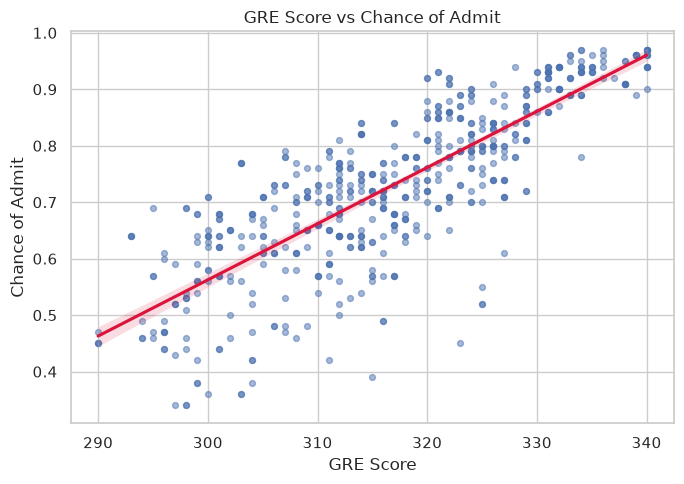

,GRE Score
Pearson r,0.8214
p (Pearson),0.0000
Spearman rho,0.8338
p (Spearman),0.0000
n pares,612.0000


In [7]:
plot_scatter_target("GRE Score")

corr_with_target("GRE Score").round(4).to_frame("GRE Score")

#### 2.2 `TOEFL Score` → target

Asociación **positiva fuerte** (Pearson 0.813, Spearman 0.823, n = 604), muy similar a
la del GRE. Tendencia creciente aproximadamente lineal, también con bandas verticales
por ser entera. Menor variabilidad relativa que el GRE (rango 92–120), lo que concentra
los puntos.

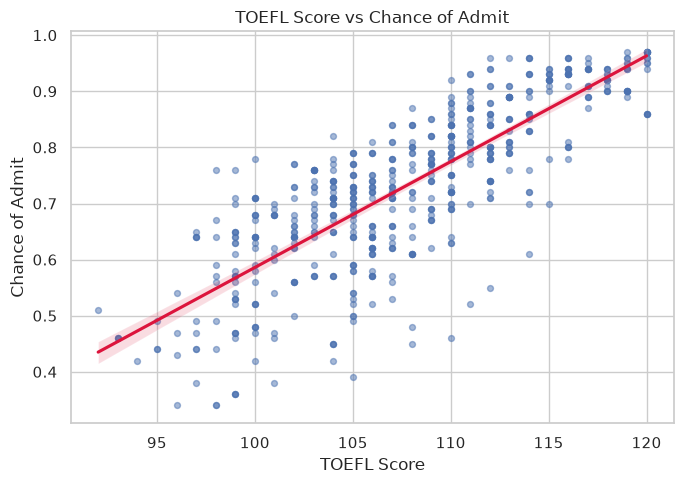

,TOEFL Score
Pearson r,0.8132
p (Pearson),0.0000
Spearman rho,0.8225
p (Spearman),0.0000
n pares,604.0000


In [8]:
plot_scatter_target("TOEFL Score")

corr_with_target("TOEFL Score").round(4).to_frame("TOEFL Score")

#### 2.3 `CGPA` → target

Es la **asociación más fuerte** de todas (Pearson 0.883, Spearman 0.890, n = 621).
La relación es marcadamente **lineal y positiva**: la nube es una banda estrecha y
creciente, con poca dispersión alrededor de la recta. Unos pocos valores de CGPA bajos
(6.8–7.5) se asocian a las probabilidades más bajas, pero siguen la misma tendencia
(sin apartarse como anomalías).

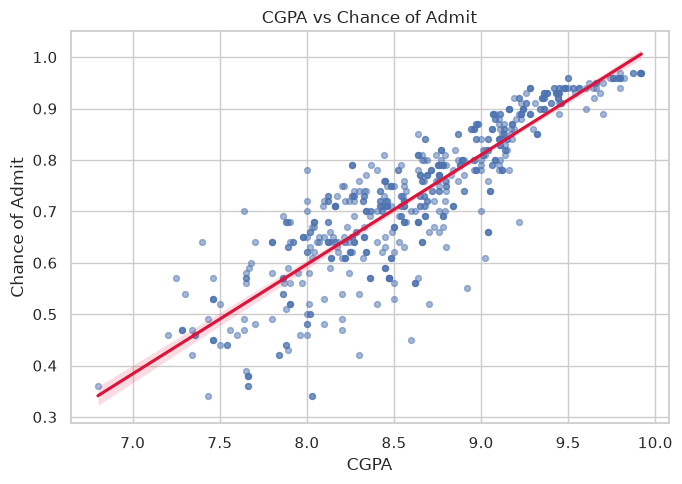

,CGPA
Pearson r,0.8832
p (Pearson),0.0000
Spearman rho,0.8897
p (Spearman),0.0000
n pares,621.0000


In [9]:
plot_scatter_target("CGPA")

corr_with_target("CGPA").round(4).to_frame("CGPA")

### 3. Predictores ordinales → target

`University Rating`, `SOP` y `LOR` son **ordinales**. Para cada uno se analiza el
comportamiento de `Chance of Admit` por categoría mediante **boxplot + stripplot**
(los puntos muestran el tamaño de cada grupo) y una tabla de media/mediana/dispersión.
Se evalúa si el target tiende a crecer al aumentar la categoría.

In [10]:
def stats_by_category(col: str) -> pd.DataFrame:
    """Media, mediana, dispersión y tamaño del target por categoría de un ordinal."""
    data = admission_df[[col, TARGET]].dropna()
    return (
        data.groupby(col)[TARGET]
        .agg(
            n=("count"),
            media=("mean"),
            mediana=("median"),
            desv=("std"),
            minimo=("min"),
            maximo=("max"),
        )
        .round(4)
    )


def plot_box_ordinal(col: str) -> None:
    """Boxplot del target por categoría, con stripplot superpuesto (tamaño de grupo)."""
    data = admission_df[[col, TARGET]].dropna()
    order = sorted(data[col].unique().tolist())
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.boxplot(data=data, x=col, y=TARGET, order=order, color="lightblue", fliersize=0, ax=ax)
    sns.stripplot(
        data=data, x=col, y=TARGET, order=order, color="black", size=2.5, alpha=0.3, ax=ax
    )
    ax.set_title(f"Chance of Admit por {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Chance of Admit")
    fig.tight_layout()
    plt.show()

#### 3.1 `University Rating` → target

Tendencia **monótona creciente clara**: la media del target sube de ~0.56 (rating 1) a
~0.88 (rating 5). Mediana y media crecen de forma consistente en cada nivel, con una
dispersión dentro de cada grupo relativamente contenida. Los tamaños de grupo son
razonables (33–200). Es coherente tratar esta variable como ordinal.

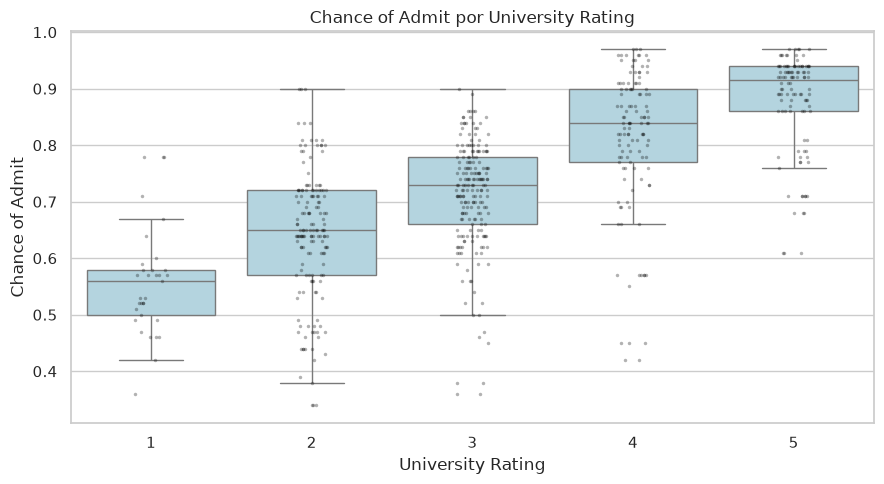

,n,media,mediana,desv,minimo,maximo
University Rating,,,,,,
1,33,0.5594,0.560,0.0988,0.36,0.78
2,158,0.6409,0.650,0.1157,0.34,0.90
3,200,0.7113,0.730,0.0973,0.36,0.90
4,118,0.8122,0.840,0.1279,0.42,0.97
5,108,0.8773,0.915,0.0884,0.61,0.97


In [11]:
plot_box_ordinal("University Rating")

stats_by_category("University Rating")

#### 3.2 `SOP` → target

Tendencia **creciente** a lo largo de los 9 niveles (media de ~0.54 en 1.0–1.5 hasta
~0.87 en 5.0). El crecimiento es gradual; los niveles bajos (1.0 y 1.5) tienen medias
casi idénticas y pocas observaciones (6 y 31), por lo que su estimación es menos
estable. Dispersión moderada dentro de cada nivel.

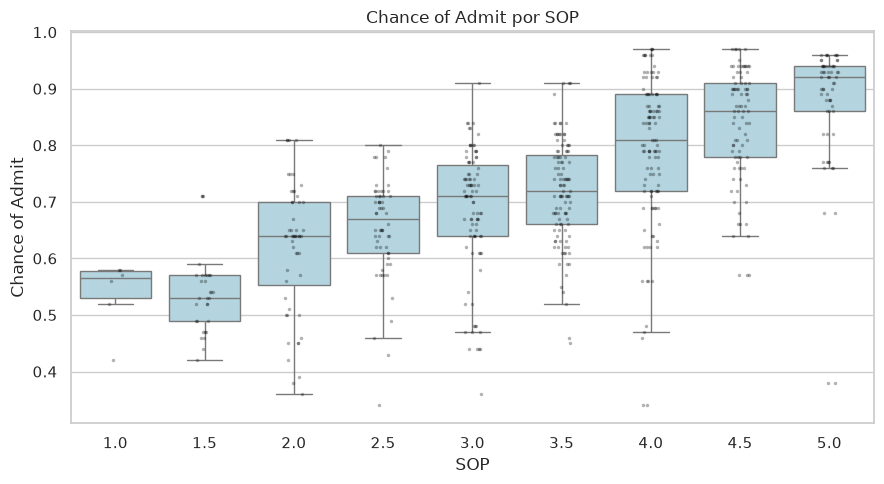

,n,media,mediana,desv,minimo,maximo
SOP,,,,,,
1.0,6,0.5383,0.565,0.0621,0.42,0.58
1.5,31,0.5384,0.530,0.0722,0.42,0.71
2.0,52,0.6202,0.640,0.1157,0.36,0.81
2.5,60,0.6545,0.670,0.0881,0.34,0.80
3.0,91,0.6842,0.710,0.1130,0.36,0.91
3.5,108,0.7176,0.720,0.0908,0.45,0.91
4.0,111,0.7889,0.810,0.1324,0.34,0.97
4.5,87,0.8372,0.860,0.1012,0.57,0.97
5.0,61,0.8734,0.920,0.1159,0.38,0.96


In [12]:
plot_box_ordinal("SOP")

stats_by_category("SOP")

#### 3.3 `LOR` → target

Tendencia **creciente** similar a `SOP` (media de ~0.57 en 1.5–2.0 hasta ~0.88 en 5.0).
Nota: el nivel `LOR = 1.0` tiene **una sola observación** (n = 1), por lo que su media
(0.42) no es representativa y debe interpretarse con cautela. A partir de 2.0 la
tendencia es clara y consistente.

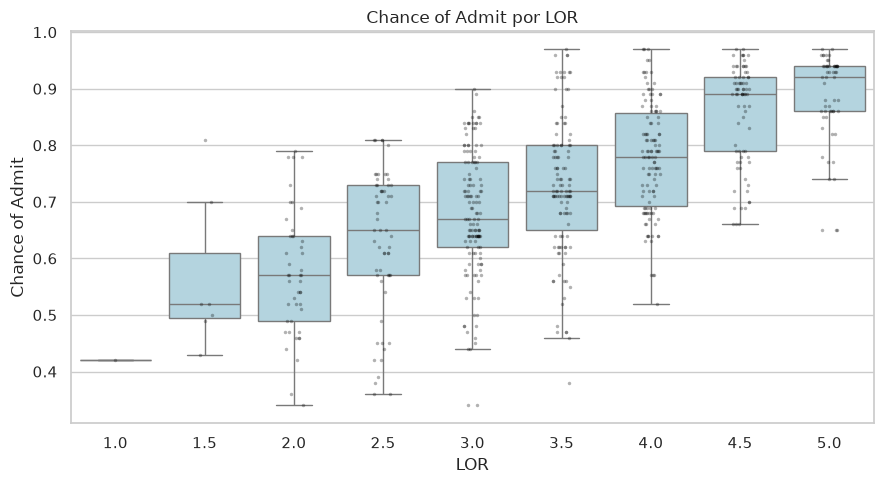

,n,media,mediana,desv,minimo,maximo
LOR,,,,,,
1.0,1,0.4200,0.42,NaN,0.42,0.42
1.5,7,0.5671,0.52,0.1356,0.43,0.81
2.0,45,0.5729,0.57,0.1093,0.34,0.79
2.5,58,0.6328,0.65,0.1262,0.36,0.81
3.0,137,0.6782,0.67,0.1127,0.34,0.90
3.5,115,0.7274,0.72,0.1229,0.38,0.97
4.0,118,0.7781,0.78,0.0980,0.52,0.97
4.5,77,0.8577,0.89,0.0893,0.66,0.97
5.0,57,0.8849,0.92,0.0815,0.65,0.97


In [13]:
plot_box_ordinal("LOR")

stats_by_category("LOR")

### 4. Predictor binario → target: `Research`

`Research` es binaria (0 = sin experiencia, 1 = con experiencia). Se compara la
distribución de `Chance of Admit` entre ambos grupos con boxplot y una prueba de
Mann-Whitney (compara las distribuciones de los dos grupos, sin asumir normalidad ni
causalidad).

In [14]:
research_data = admission_df[[TARGET, "Research"]].dropna()
group0 = research_data.loc[research_data["Research"] == 0, TARGET]
group1 = research_data.loc[research_data["Research"] == 1, TARGET]

res = stats.mannwhitneyu(group0, group1, alternative="two-sided")

print(f"Mann-Whitney U = {res.statistic:.1f}, p = {res.pvalue:.3e}")

summary_research = pd.DataFrame(
    {
        "n": [len(group0), len(group1)],
        "media": [group0.mean(), group1.mean()],
        "mediana": [group0.median(), group1.median()],
        "desv. std": [group0.std(), group1.std()],
        "mínimo": [group0.min(), group1.min()],
        "máximo": [group0.max(), group1.max()],
    },
    index=["Research = 0", "Research = 1"],
).round(4)

summary_research

Mann-Whitney U = 13644.5, p = 3.451e-47


,n,media,mediana,desv. std,mínimo,máximo
Research = 0,267,0.6421,0.65,0.1125,0.34,0.89
Research = 1,327,0.8046,0.82,0.1219,0.36,0.97


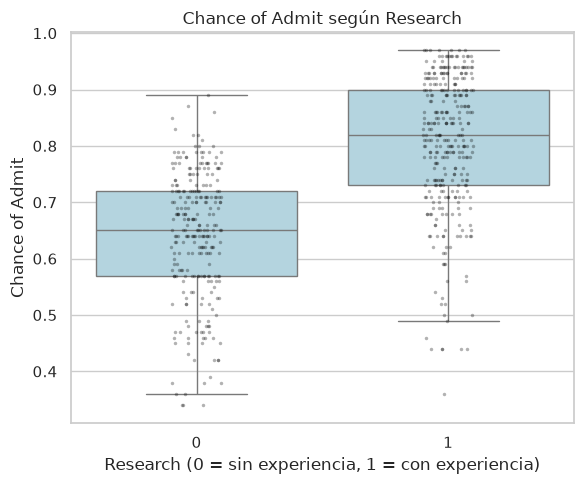

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=research_data, x="Research", y=TARGET, order=[0, 1], color="lightblue", fliersize=0, ax=ax
)
sns.stripplot(
    data=research_data,
    x="Research",
    y=TARGET,
    order=[0, 1],
    color="black",
    size=2.5,
    alpha=0.3,
    ax=ax,
)
ax.set_title("Chance of Admit según Research")
ax.set_xlabel("Research (0 = sin experiencia, 1 = con experiencia)")
ax.set_ylabel("Chance of Admit")
fig.tight_layout()
plt.show()

**Observación**: el grupo con experiencia en investigación (`Research = 1`, n = 327)
tiene media y mediana claramente superiores a las del grupo sin experiencia
(`Research = 0`, n = 267), como muestra la tabla anterior. La prueba de Mann-Whitney
(ver estadístico U y p-value en la salida de la celda anterior) indica que la
diferencia entre las distribuciones de ambos grupos es estadísticamente muy
significativa (p-value extremadamente pequeño, mostrado en notación científica).

**Interpretación cuidadosa**: los datos **sugieren** que los estudiantes con experiencia
en investigación tienden a tener mayores probabilidades estimadas de admisión. **No se
afirma** que `Research` cause la admisión: podría reflejar un perfil académico
globalmente más fuerte.

### 5. Relaciones entre predictores (posible multicolinealidad)

El análisis bivariable también examina pares de predictores para detectar asociaciones
fuertes que puedan indicar **redundancia** y anticipar problemas de multicolinealidad
(que se estudiarán formalmente en el análisis multivariable). Se analizan las cinco
relaciones requeridas.

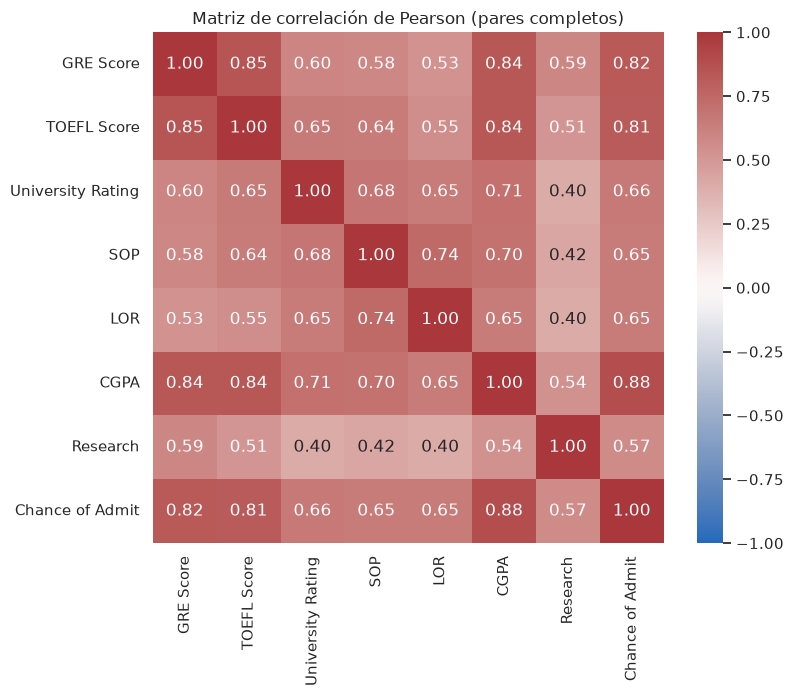

In [16]:
corr_matrix = admission_df[[*PREDICTORS, TARGET]].corr(method="pearson")

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Matriz de correlación de Pearson (pares completos)")
fig.tight_layout()
plt.show()

La matriz muestra un bloque de **correlaciones altas entre predictores**: `GRE
Score`, `TOEFL Score` y `CGPA` se correlacionan entre sí en torno a 0.84, y `University
Rating` y `SOP`/`LOR` también muestran asociaciones altas (0.65–0.74). Esto anticipa
redundancia y posible multicolinealidad.

In [17]:
def corr_pair(a: str, b: str) -> pd.Series:
    """Correlación Pearson y Spearman entre dos columnas (pares completos)."""
    data = admission_df[[a, b]].dropna()
    r, _ = stats.pearsonr(data[a], data[b])
    rho, _ = stats.spearmanr(data[a], data[b])
    return pd.Series({"Pearson r": r, "Spearman rho": rho, "n pares": len(data)})

#### 5.1 `GRE Score` ↔ `TOEFL Score`

Asociación **fuerte y positiva** (Pearson 0.846, Spearman 0.846). Ambos miden aptitud
académica/idioma y se mueven juntos: un estudiante con GRE alto tiende a tener TOEFL
alto. Alta redundancia.

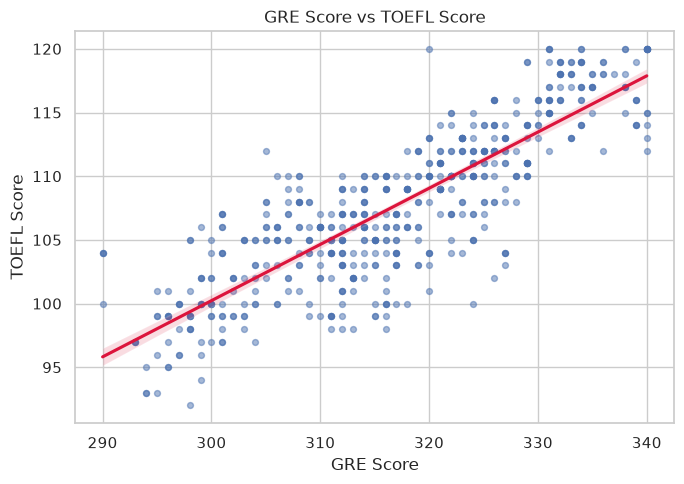

,GRE vs TOEFL
Pearson r,0.8457
Spearman rho,0.8457
n pares,596.0000


In [18]:
sub = admission_df[["GRE Score", "TOEFL Score"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=sub,
    x="GRE Score",
    y="TOEFL Score",
    scatter_kws={"alpha": 0.5, "s": 18},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("GRE Score vs TOEFL Score")
fig.tight_layout()
plt.show()

corr_pair("GRE Score", "TOEFL Score").round(4).to_frame("GRE vs TOEFL")

#### 5.2 `GRE Score` ↔ `CGPA`

Asociación **fuerte y positiva** (Pearson 0.844, Spearman 0.843). GRE alto tiende a
acompañarse de CGPA alto. Redundancia alta.

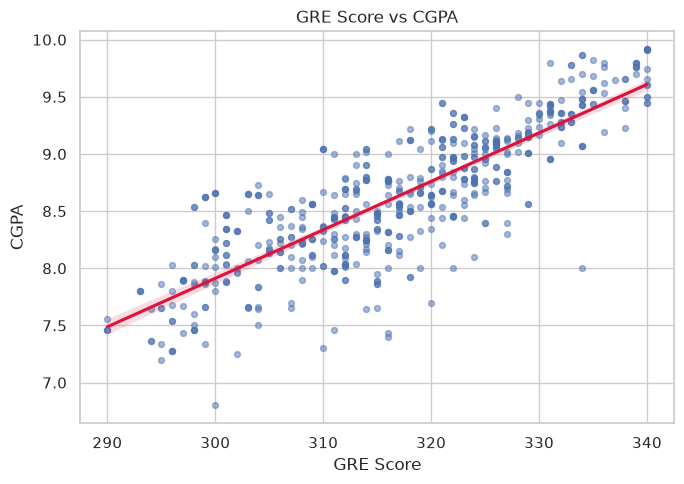

,GRE vs CGPA
Pearson r,0.8435
Spearman rho,0.8430
n pares,610.0000


In [19]:
sub = admission_df[["GRE Score", "CGPA"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=sub,
    x="GRE Score",
    y="CGPA",
    scatter_kws={"alpha": 0.5, "s": 18},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("GRE Score vs CGPA")
fig.tight_layout()
plt.show()

corr_pair("GRE Score", "CGPA").round(4).to_frame("GRE vs CGPA")

#### 5.3 `TOEFL Score` ↔ `CGPA`

Asociación **fuerte y positiva** (Pearson 0.843, Spearman 0.845). Mismo patrón que las
anteriores: el bloque GRE–TOEFL–CGPA está muy correlacionado.

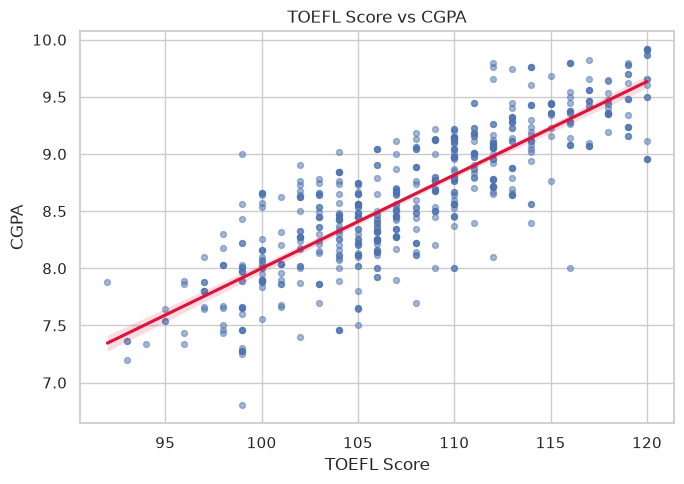

,TOEFL vs CGPA
Pearson r,0.8426
Spearman rho,0.8448
n pares,603.0000


In [20]:
sub = admission_df[["TOEFL Score", "CGPA"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=sub,
    x="TOEFL Score",
    y="CGPA",
    scatter_kws={"alpha": 0.5, "s": 18},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("TOEFL Score vs CGPA")
fig.tight_layout()
plt.show()

corr_pair("TOEFL Score", "CGPA").round(4).to_frame("TOEFL vs CGPA")

#### 5.4 `University Rating` ↔ `CGPA`

Asociación **fuerte y positiva** (Pearson 0.706, Spearman 0.715). La mediana de CGPA
crece de forma clara con el rating de la universidad: universidades de mayor rating se
asocian a estudiantes con CGPA más alto.

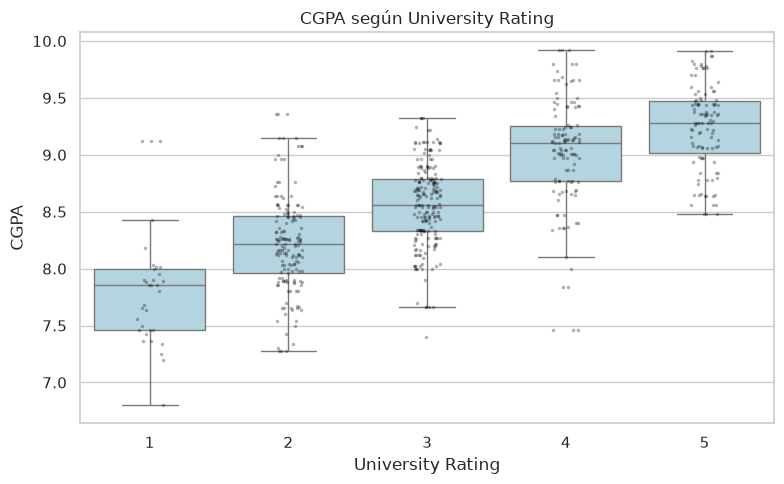

,University Rating vs CGPA
Pearson r,0.7058
Spearman rho,0.7149
n pares,615.0000


In [21]:
sub = admission_df[["University Rating", "CGPA"]].dropna()
order = sorted(sub["University Rating"].unique().tolist())
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=sub, x="University Rating", y="CGPA", order=order, color="lightblue", fliersize=0, ax=ax
)
sns.stripplot(
    data=sub,
    x="University Rating",
    y="CGPA",
    order=order,
    color="black",
    size=2.5,
    alpha=0.3,
    ax=ax,
)
ax.set_title("CGPA según University Rating")
fig.tight_layout()
plt.show()

corr_pair("University Rating", "CGPA").round(4).to_frame("University Rating vs CGPA")

#### 5.5 `SOP` ↔ `LOR`

Asociación **fuerte y positiva** (Pearson 0.740, Spearman 0.741). Ambas son valoraciones
subjetivas de fortaleza (propósito y recomendación) en la misma escala 1–5, por lo que
es esperable que se muevan juntas. Redundancia notable.

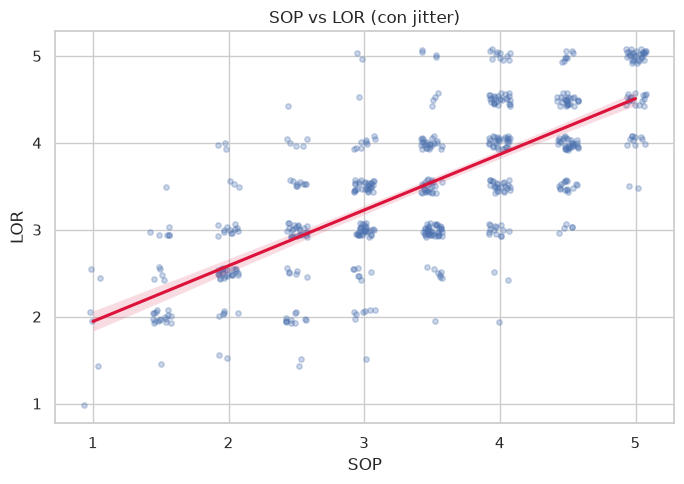

,SOP vs LOR
Pearson r,0.7399
Spearman rho,0.7405
n pares,599.0000


In [22]:
sub = admission_df[["SOP", "LOR"]].dropna()
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(
    data=sub,
    x="SOP",
    y="LOR",
    x_jitter=0.08,
    y_jitter=0.08,
    scatter_kws={"alpha": 0.3, "s": 15},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("SOP vs LOR (con jitter)")
fig.tight_layout()
plt.show()

corr_pair("SOP", "LOR").round(4).to_frame("SOP vs LOR")

**Síntesis de multicolinealidad**: existe un bloque de predictores altamente
correlacionados entre sí (GRE–TOEFL–CGPA ≈ 0.84; SOP–LOR ≈ 0.74; University Rating–CGPA
≈ 0.71). Esto **no invalida** el análisis bivariable, pero anticipa que en una etapa de
modelado varios predictores aportarán información redundante. La multicolinealidad
formal se estudiará en el análisis multivariable.

## 💡 Propuestas e ideas

### Heurística / baseline (evidencia, sin implementar)

Los resultados bivariables sugieren que una **heurística simple** podría tener sentido
en una etapa posterior, porque:

- `CGPA` (0.883), `GRE Score` (0.821) y `TOEFL Score` (0.813) muestran asociación
  **fuerte, positiva y aproximadamente lineal** con el target.
- `University Rating`, `SOP` y `LOR` muestran una **tendencia monótona** clara (el
  target crece con la categoría).
- `Research = 1` se asocia a una probabilidad media ~0.16 mayor que `Research = 0`.

Esto apunta a que una futura heurística podría combinar (p. ej. de forma ponderada)
`CGPA`, `GRE Score` y `TOEFL Score`, más un ajuste por `Research` y el rating, reescalada
a [0,1]. **Aquí no se implementa ni se valida ningún modelo ni baseline**: la evaluación
formal corresponde a una etapa posterior.

### Implicaciones para Machine Learning (a resolver después)

Identificadas a partir del análisis, **sin implementarlas**:

- **Escalado/normalización**: `GRE Score`, `TOEFL Score` y `CGPA` tienen escalas
  distintas; lo requerirá un modelo basado en distancia.
- **Multicolinealidad / selección**: el bloque GRE–TOEFL–CGPA es redundante; convendrá
  evaluar selección de variables o regularización en la etapa de modelado.
- **Imputación**: decidir el tratamiento de nulos (media/mediana/moda, KNN o descarte),
  cuidando no filtrar información.
- **Deduplicación**: las 152 filas duplicadas inflan las frecuencias; deberán tratarse
  antes del split train/test para evitar leakage.
- **Encoding/tratamiento ordinal**: `University Rating`, `SOP` y `LOR` son ordinales; se
  decidirá si se tratan como numéricas o como categorías ordenadas.
- **Outliers**: no se eliminan; si algún modelo fuera sensible, se evaluará su impacto.

### Conclusiones del análisis bivariable

**Hallazgos**

- La variable con **mayor asociación** con el target es `CGPA` (r ≈ 0.88), seguida de
  `GRE Score` (0.82) y `TOEFL Score` (0.81); las tres con relación positiva y
  aproximadamente lineal.
- Las variables ordinales `University Rating`, `SOP` y `LOR` muestran una **tendencia
  monótona creciente** del target a lo largo de sus categorías.
- `Research` (binaria) se asocia a una diferencia de ~0.16 en la probabilidad media a
  favor del grupo con experiencia, aunque es el predictor con **menor** asociación
  global (r ≈ 0.57).
- Existe un **bloque de predictores muy correlacionados** (GRE–TOEFL–CGPA ≈ 0.84, y
  SOP–LOR ≈ 0.74), indicio de redundancia.

**Limitaciones**

- Correlación **no implica causalidad**; solo se describen asociaciones observacionales.
- Los nulos reducen el `n` de cada par (594–621 pares válidos); las relaciones se
  estiman sobre observaciones completas del par, no sobre el total.
- Las 152 filas duplicadas pueden **inflar ligeramente** las correlaciones al repetir
  patrones; no se eliminaron por decisión de alcance.
- El análisis es exclusivamente bivariable: no controla la influencia de terceras
  variables (p. ej. la relación Research–target podría confundirse con CGPA/GRE).

**Preguntas para el análisis multivariable**

- ¿Cuánto aporta cada predictor una vez que se controla por los demás?
- ¿El bloque GRE–TOEFL–CGPA presenta multicolinealidad problemática?
- ¿La relación de `Research` con el target se mantiene al controlar por CGPA/GRE?
- ¿Existen interacciones relevantes entre predictores?

## 📖 Referencias

- Notebook 1 (univariable): `notebooks/3-analysis/03.1-SCO_univariate_analysis-2026_08_19.ipynb`.
- Issue #2 — *Exploración inicial de datos*:
  `notebooks/2-exploration/02.1-SCO_data_exploration-2026_08_19.ipynb`.
- `data/01_raw/Informacion.txt` — descripción del dataset y sus variables.
- Zapata, J. R. — *Análisis exploratorio de datos* (referencia del curso):
  <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/>.
- Documentación de pandas (`corr`, `groupby`), scipy (`pearsonr`, `spearmanr`,
  `mannwhitneyu`) y seaborn (`regplot`, `boxplot`, `stripplot`, `heatmap`).